In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
from datetime import datetime, timedelta

In [7]:
import random

In [8]:
test_date=datetime(2026,4,22)
daily_traffic=150

In [9]:
# Конверсии по группам
conversion_a = 0.05
conversion_b = 0.09

In [10]:
users = []
for i in range(1, daily_traffic + 1):
    user_id = 3000 + i  # ← 3001...3150
    
    group = 'A' if random.random() < 0.5 else 'B'
    
    if group == 'A':
        purchase_prob = conversion_a
    else:
        purchase_prob = conversion_b
    
    purchase_flag = 1 if random.random() < purchase_prob else 0
    
    if purchase_flag == 1:
        revenue = round(random.uniform(200, 1000), 2)
    else:
        revenue = 0
    
    if purchase_flag == 1:
        page_views = random.randint(5, 15)
    else:
        page_views = random.randint(1, 8)
    
    session_duration_sec = page_views * random.randint(15, 45)
    
    hour = random.randint(9, 21)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)
    visited_at = test_date.replace(hour=hour, minute=minute, second=second)
    
    users.append({
        'user_id': user_id,
        'group_name': group,
        'visit_date': test_date.date(),
        'visited_at': visited_at,
        'purchase_flag': purchase_flag,
        'revenue': revenue,
        'page_views': page_views,
        'session_duration_sec': session_duration_sec
    })

df_day3 = pd.DataFrame(users)

print("📊 ДАННЫЕ ТРЕТЬЕГО ДНЯ ТЕСТА")
print("=" * 50)
print(f"Дата: {test_date.date()}")
print(f"Всего посетителей: {len(df_day3)}")
print(f"Распределение по группам:")
print(df_day3['group_name'].value_counts())
print(f"\nКонверсия в день 3:")
for group in ['A', 'B']:
    group_data = df_day3[df_day3['group_name'] == group]
    conv = group_data['purchase_flag'].mean() * 100
    print(f"  Группа {group}: {len(group_data)} чел, конверсия {conv:.1f}%")

df_day3.to_csv('pen_shop_day3.csv', index=False)
print(f"\n✅ Файл 'pen_shop_day3.csv' сохранён")

📊 ДАННЫЕ ТРЕТЬЕГО ДНЯ ТЕСТА
Дата: 2026-04-22
Всего посетителей: 150
Распределение по группам:
group_name
B    76
A    74
Name: count, dtype: int64

Конверсия в день 3:
  Группа A: 74 чел, конверсия 1.4%
  Группа B: 76 чел, конверсия 11.8%

✅ Файл 'pen_shop_day3.csv' сохранён


Визуализация 3 дня




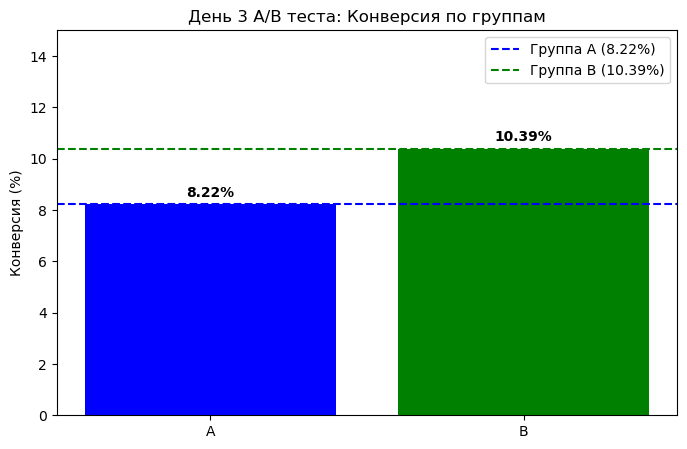

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Данные дня 3
data_day3 = pd.DataFrame({
    'group': ['A', 'B'],
    'visitors': [73, 77],
    'purchases': [6, 8],
    'conversion': [8.22, 10.39]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(data_day3['group'], data_day3['conversion'], color=['blue', 'green'])
plt.axhline(y=8.22, color='blue', linestyle='--', label='Группа A (8.22%)')
plt.axhline(y=10.39, color='green', linestyle='--', label='Группа B (10.39%)')
plt.ylabel('Конверсия (%)')
plt.title('День 3 A/B теста: Конверсия по группам')
plt.legend()
plt.ylim(0, 15)

for bar, conv in zip(bars, data_day3['conversion']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{conv}%', ha='center', fontweight='bold')

plt.show()

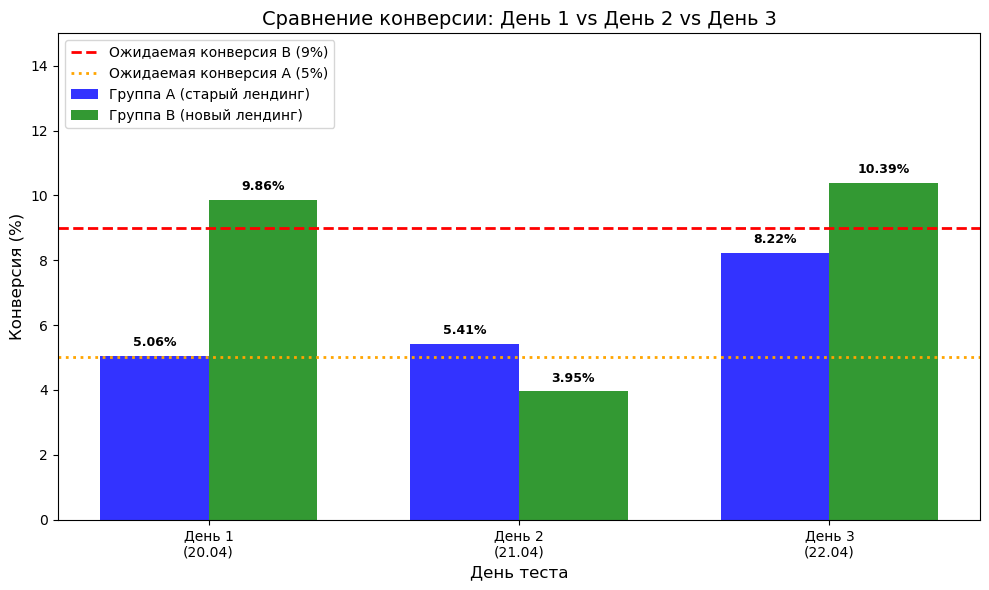

 АНАЛИЗ ТРЁХ ДНЕЙ:
Группа A (старый лендинг):
  День 1: 5.06%
  День 2: 5.41%
  День 3: 8.22% ← аномальный рост!
Группа B (новый лендинг):
  День 1: 9.86%
  День 2: 3.95% ← сильное падение
  День 3: 10.39%
 ВЫВОД:
  На малых выборках (70-80 человек) возможны сильные колебания.
  Доверять можно только накопленным данным после 625+ пользователей.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Данные за три дня
data = pd.DataFrame({
    'day': [1, 1, 2, 2, 3, 3],
    'group': ['A', 'B', 'A', 'B', 'A', 'B'],
    'conversion': [5.06, 9.86, 5.41, 3.95, 8.22, 10.39]
})

# Подготовка для группового графика
days = [1, 2, 3]
x = np.arange(len(days))
width = 0.35

# Значения конверсии по группам
conv_A = [5.06, 5.41, 8.22]
conv_B = [9.86, 3.95, 10.39]

# Построим график
fig, ax = plt.subplots(figsize=(10, 6))
bars_A = ax.bar(x - width/2, conv_A, width, label='Группа A (старый лендинг)', color='blue', alpha=0.8)
bars_B = ax.bar(x + width/2, conv_B, width, label='Группа B (новый лендинг)', color='green', alpha=0.8)

# Линия ожидаемой конверсии для группы B (9%)
ax.axhline(y=9, color='red', linestyle='--', linewidth=2, label='Ожидаемая конверсия B (9%)')

# Линия ожидаемой конверсии для группы A (5%)
ax.axhline(y=5, color='orange', linestyle=':', linewidth=2, label='Ожидаемая конверсия A (5%)')

# Настройки
ax.set_xlabel('День теста', fontsize=12)
ax.set_ylabel('Конверсия (%)', fontsize=12)
ax.set_title('Сравнение конверсии: День 1 vs День 2 vs День 3', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['День 1\n(20.04)', 'День 2\n(21.04)', 'День 3\n(22.04)'])
ax.set_ylim(0, 15)
ax.legend(loc='upper left', fontsize=10)

# Добавим подписи на столбцах
for bars in [bars_A, bars_B]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
                f'{height}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print(" АНАЛИЗ ТРЁХ ДНЕЙ:")
print("=" * 50)
print("Группа A (старый лендинг):")
print(f"  День 1: 5.06%")
print(f"  День 2: 5.41%")
print(f"  День 3: 8.22% ← аномальный рост!")
print("Группа B (новый лендинг):")
print(f"  День 1: 9.86%")
print(f"  День 2: 3.95% ← сильное падение")
print(f"  День 3: 10.39%")
print(" ВЫВОД:")
print("  На малых выборках (70-80 человек) возможны сильные колебания.")
print("  Доверять можно только накопленным данным после 625+ пользователей.")